In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost
import catboost
import matplotlib.pyplot as plt

# Data collection

In [2]:
df_raw = pd.read_excel('for_analyses_kama_realistic(newer).xlsx')

# удаляем нерелевантные признаки
df = df_raw.copy()
'''df.drop(columns=['reg_date', 'Аl3+','G_acid', 'G_alkali', 'SpecG_acid(eq)', 'SpecG_alkali(eq)', 
                 'SpecG_acid', 'SpecG_alkali', 'Acid_alkali_ratio', 'F_cycle'], 
            inplace=True)'''

df.drop(columns=['reg_date', 'G_acid', 'G_alkali', 'SpecG_acid(eq)', 'SpecG_alkali(eq)', 
                 'SpecG_acid', 'SpecG_alkali', 'Acid_alkali_ratio', 'F_cycle', 'uepp_end', 'SiO2_end'], 
        inplace=True)

df

,turb,pH,Аl3+,Alkal,hardness,NO,Сl,SO2,Са2,Mg2_max,Na_K_max,Fe_total,total_sal,PO,SiO2,Sum_cations,Sum_anions
0,0.20,7.57,0.02,2.78,3.85,0.40,18.78,8.94,65.46,8.98,2.50,0.04,223.01,4.90,4.00,3.665874,3.078215
1,0.20,7.56,0.02,3.80,4.92,0.40,19.65,12.27,83.63,11.39,5.33,0.04,273.05,4.90,4.00,3.744814,3.068691
2,0.20,7.54,0.02,2.64,3.84,0.40,17.83,8.33,65.16,9.16,2.50,0.04,221.03,4.90,4.00,3.891562,3.267278
3,0.31,7.53,0.03,4.29,5.38,0.40,19.73,14.20,90.98,12.59,7.95,0.04,294.54,4.95,4.13,3.437979,2.816907
4,0.20,7.47,0.02,2.15,2.57,0.40,16.90,11.29,43.03,6.72,14.43,0.04,169.98,4.90,4.00,3.315000,2.730000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,2.40,7.01,0.13,0.90,0.60,1.02,8.01,13.02,9.31,2.71,20.34,0.13,90.00,10.81,5.24,2.957000,2.327000
107,3.60,7.00,0.19,4.19,3.89,2.13,11.53,22.82,60.23,13.28,33.72,0.19,257.01,13.27,6.70,2.965000,2.325000
108,2.14,7.00,0.12,0.90,0.60,1.04,7.38,12.07,9.28,2.73,19.33,0.12,90.00,10.52,5.21,2.707000,2.107000
109,2.79,7.00,0.15,1.44,1.14,1.12,8.20,14.42,17.63,4.48,22.01,0.15,105.85,11.65,5.60,2.983000,2.431000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   turb         111 non-null    float64
 1   pH           111 non-null    float64
 2   Аl3+         111 non-null    float64
 3   Alkal        111 non-null    float64
 4   hardness     111 non-null    float64
 5   NO           111 non-null    float64
 6   Сl           111 non-null    float64
 7   SO2          111 non-null    float64
 8   Са2          111 non-null    float64
 9   Mg2_max      111 non-null    float64
 10  Na_K_max     111 non-null    float64
 11  Fe_total     111 non-null    float64
 12  total_sal    111 non-null    float64
 13  PO           111 non-null    float64
 14  SiO2         111 non-null    float64
 15  Sum_cations  111 non-null    float64
 16  Sum_anions   111 non-null    float64
dtypes: float64(17)
memory usage: 14.9 KB


# Correlation matrix of initial features

In [4]:
def corr_matrix(df, target, method):

    df_corr = df.corr(method)
    df_corr.sort_values(by=target, axis='columns', ascending=False, inplace=True, key=lambda col: abs(col))

    plt.rcParams['font.family'] = 'Times New Roman'
    plt.rcParams['font.size'] = 14

    # Generate a mask for the upper triangle
    mask = np.triu(np.ones_like(df_corr, dtype=bool))

    # Set up the matplotlib figure
    fig, ax = plt.subplots(figsize=(11, 10))
    
    dict_method = {'pearson': 'Пирсона', 'kendall': 'Кенделла', 'spearman': 'Спирмана'}
    
    # Draw the heatmap with the mask and correct aspect ratio
    sns.heatmap(df_corr, 
                annot=True, 
                mask=mask, 
                cmap=sns.color_palette("vlag", as_cmap=True),
                fmt=".2f", 
                vmax=1.0, 
                vmin=-1.0, 
                center=0,
                square=True, 
                linewidths=1, 
                cbar_kws={"shrink": .8}).set(title=f'Корреляционная матрица {dict_method[method]} для исходных признаков')

    plt.tight_layout()
    plt.savefig(f'pictures/full_corr_matrix_{target}_{method}.png', dpi = 300, transparent = True)
    plt.show()

## F_cycle

In [5]:
df_F_cycle = df.copy()

# целевой признак
df_F_cycle['F_cycle'] = df_raw.F_cycle
df_F_cycle.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   turb         111 non-null    float64
 1   pH           111 non-null    float64
 2   Аl3+         111 non-null    float64
 3   Alkal        111 non-null    float64
 4   hardness     111 non-null    float64
 5   NO           111 non-null    float64
 6   Сl           111 non-null    float64
 7   SO2          111 non-null    float64
 8   Са2          111 non-null    float64
 9   Mg2_max      111 non-null    float64
 10  Na_K_max     111 non-null    float64
 11  Fe_total     111 non-null    float64
 12  total_sal    111 non-null    float64
 13  PO           111 non-null    float64
 14  SiO2         111 non-null    float64
 15  Sum_cations  111 non-null    float64
 16  Sum_anions   111 non-null    float64
 17  F_cycle      111 non-null    int64  
dtypes: float64(17), int64(1)
memory usage: 15.7 KB


### pearson

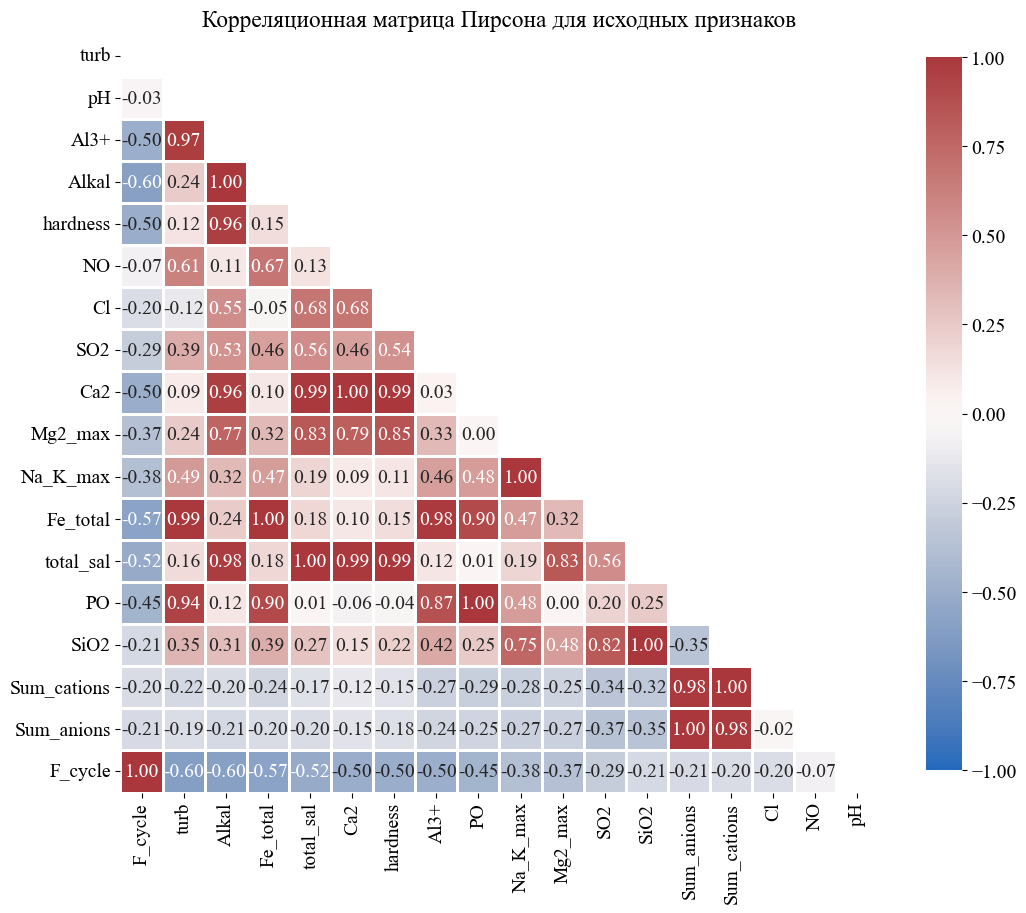

In [6]:
corr_matrix(df=df_F_cycle, target='F_cycle', method='pearson')

### kendall

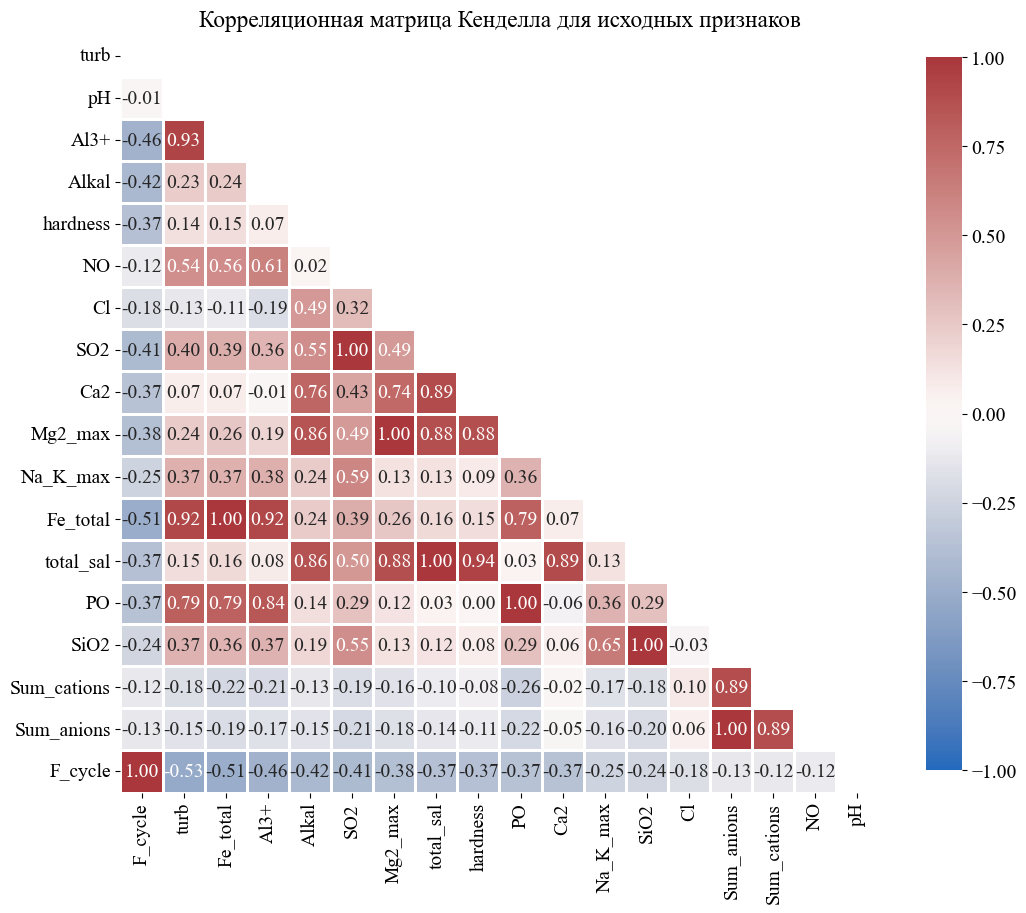

In [7]:
corr_matrix(df=df_F_cycle, target='F_cycle', method='kendall')

## Acid

In [8]:
df_Acid = df.copy()

# целевой признак
df_Acid['SpecG_acid'] = df_raw['SpecG_acid(eq)']
df_Acid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   turb         111 non-null    float64
 1   pH           111 non-null    float64
 2   Аl3+         111 non-null    float64
 3   Alkal        111 non-null    float64
 4   hardness     111 non-null    float64
 5   NO           111 non-null    float64
 6   Сl           111 non-null    float64
 7   SO2          111 non-null    float64
 8   Са2          111 non-null    float64
 9   Mg2_max      111 non-null    float64
 10  Na_K_max     111 non-null    float64
 11  Fe_total     111 non-null    float64
 12  total_sal    111 non-null    float64
 13  PO           111 non-null    float64
 14  SiO2         111 non-null    float64
 15  Sum_cations  111 non-null    float64
 16  Sum_anions   111 non-null    float64
 17  SpecG_acid   111 non-null    float64
dtypes: float64(18)
memory usage: 15.7 KB


### pearson

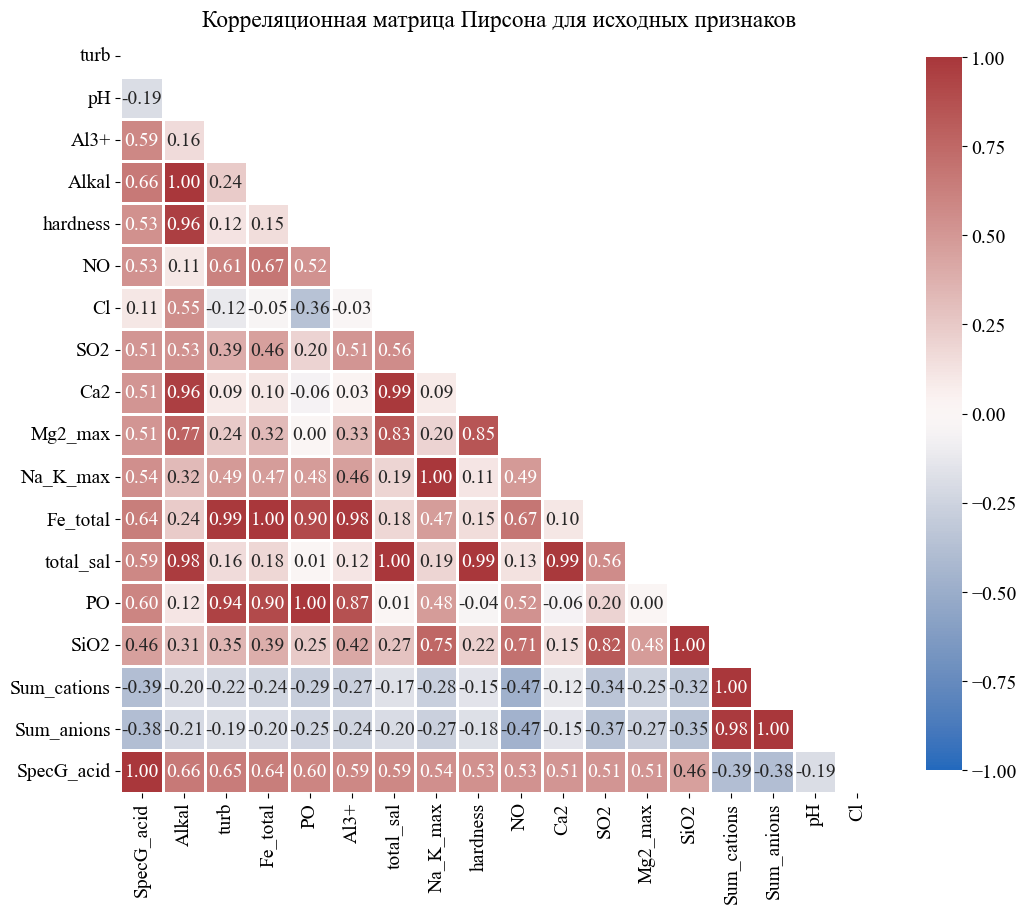

In [9]:
corr_matrix(df=df_Acid, target='SpecG_acid', method='pearson')

### kendall

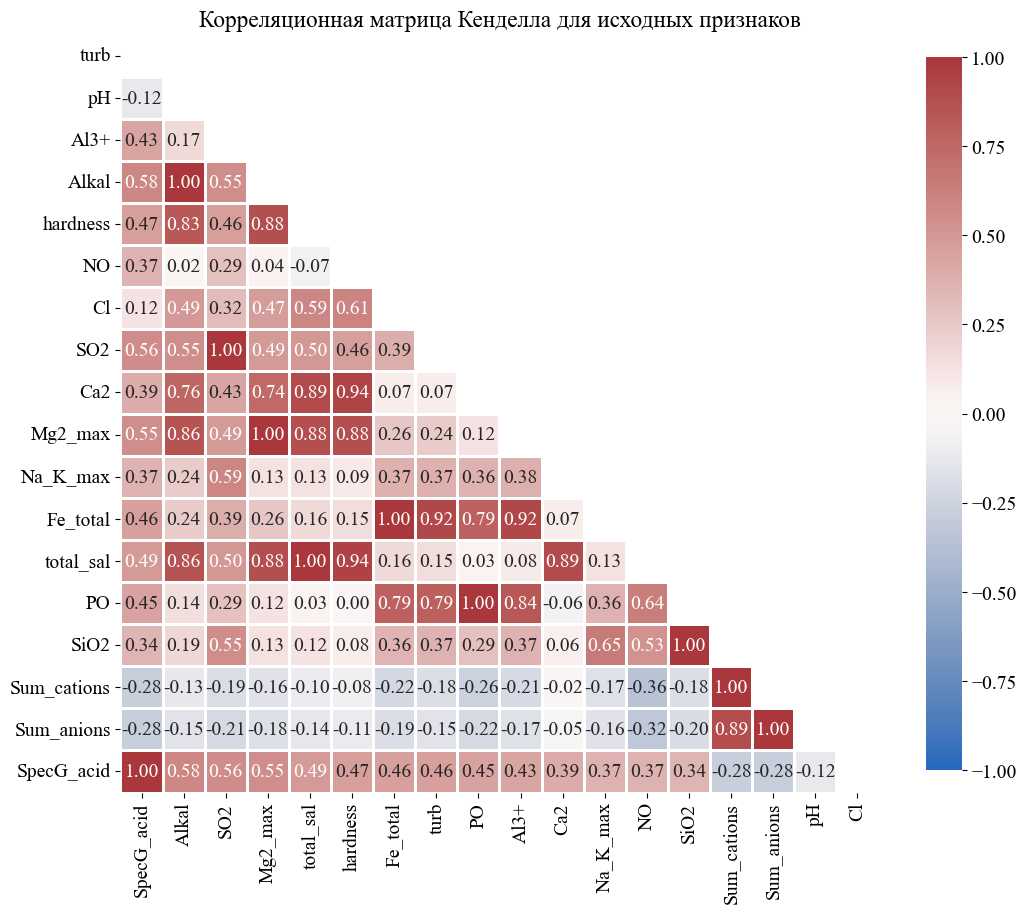

In [10]:
corr_matrix(df=df_Acid, target='SpecG_acid', method='kendall')

## Alcaline

In [11]:
df_Alcaline = df.copy()

# целевой признак
df_Alcaline['SpecG_alkali'] = df_raw['SpecG_alkali(eq)']
df_Alcaline.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   turb          111 non-null    float64
 1   pH            111 non-null    float64
 2   Аl3+          111 non-null    float64
 3   Alkal         111 non-null    float64
 4   hardness      111 non-null    float64
 5   NO            111 non-null    float64
 6   Сl            111 non-null    float64
 7   SO2           111 non-null    float64
 8   Са2           111 non-null    float64
 9   Mg2_max       111 non-null    float64
 10  Na_K_max      111 non-null    float64
 11  Fe_total      111 non-null    float64
 12  total_sal     111 non-null    float64
 13  PO            111 non-null    float64
 14  SiO2          111 non-null    float64
 15  Sum_cations   111 non-null    float64
 16  Sum_anions    111 non-null    float64
 17  SpecG_alkali  111 non-null    float64
dtypes: float64(18)
memory usage: 1

### pearson

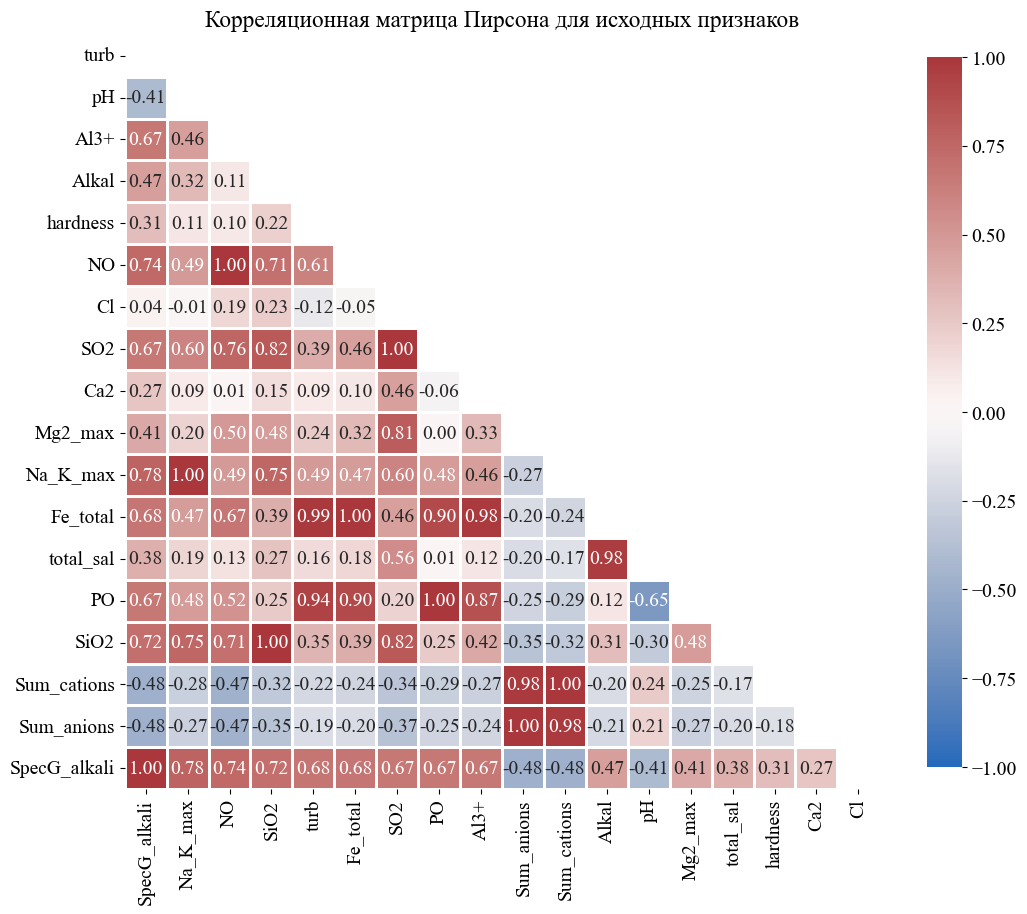

In [12]:
corr_matrix(df=df_Alcaline, target='SpecG_alkali', method='pearson')

### kendall

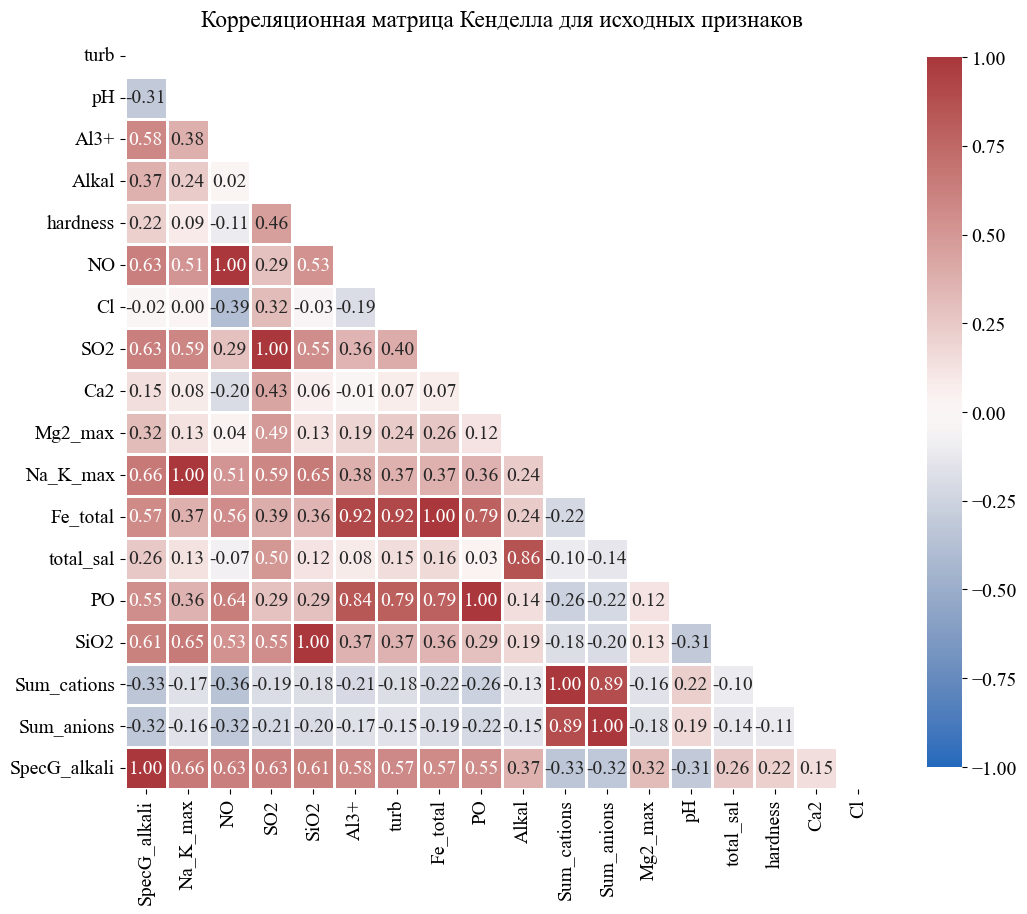

In [13]:
corr_matrix(df=df_Alcaline, target='SpecG_alkali', method='kendall')

# Feature important

In [29]:
def feature_importance_selector(X, y, engine='catboost'):
    
    if engine=='catboost':
        selector = catboost.CatBoostRegressor(silent=True)
    elif engine=='xgboost':
        selector = xgboost.XGBRegressor()
    
    selector.fit(X, y)

    feature_importances = pd.DataFrame({'importance' : selector.feature_importances_}, 
                                       index=X.columns).sort_values(by='importance', ascending=False)

    if engine=='catboost':
        feature_importances.importance /= 100
    
    plt.rcParams['font.size'] = 16
    plt.figure(figsize=(12, 5))
    
    for bar in plt.bar(range(len(feature_importances.index)), feature_importances.importance, align='center', width=0.8):
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 3), ha='center', va='bottom')
    
    
    plt.xticks(range(len(feature_importances.index)), feature_importances.index, rotation=90)
    plt.ylim(0, (((feature_importances.importance.max()*100 // 5) + 2) * 5) / 100)

    plt.ylabel('Feature weight')
    plt.title(f'Features importance for {y.name}', fontsize=16)
    plt.tight_layout()
    plt.savefig(f'pictures/standard_feature_important_{y.name}.png', dpi = 300, transparent = True)
    plt.show()

## F_cycle

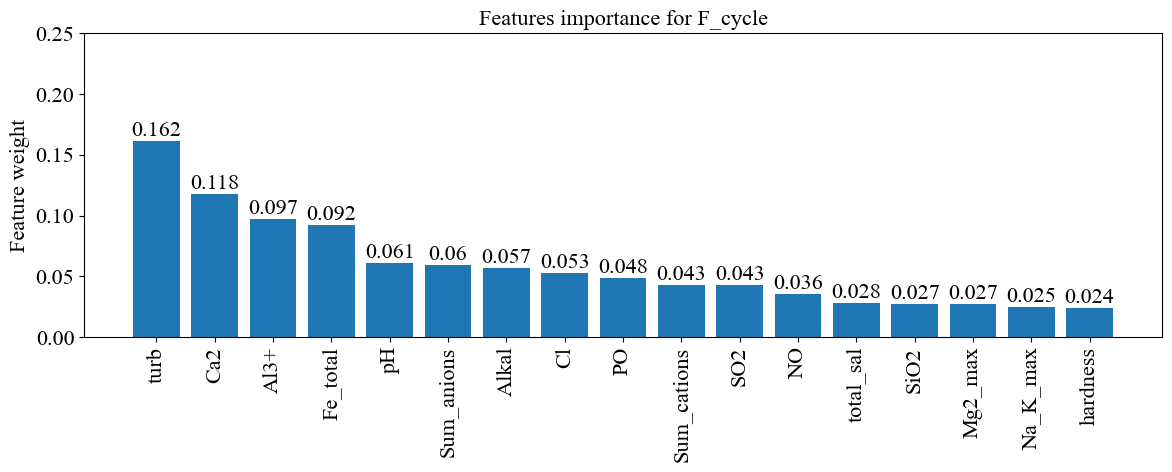

In [23]:
feature_importance_selector(X=df_F_cycle.drop(columns='F_cycle'), 
                            y=df_F_cycle.F_cycle, 
                            engine='catboost')

## Acid

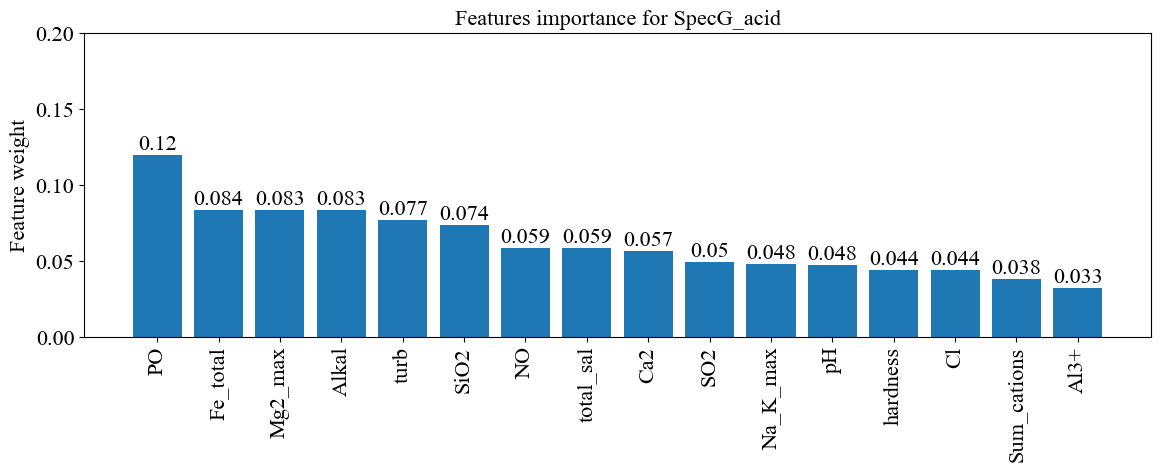

In [25]:
feature_importance_selector(X=df_Acid.drop(columns=['SpecG_acid', 'Sum_anions']), 
                            y=df_Acid.SpecG_acid, 
                            engine='catboost')

## Alcaline

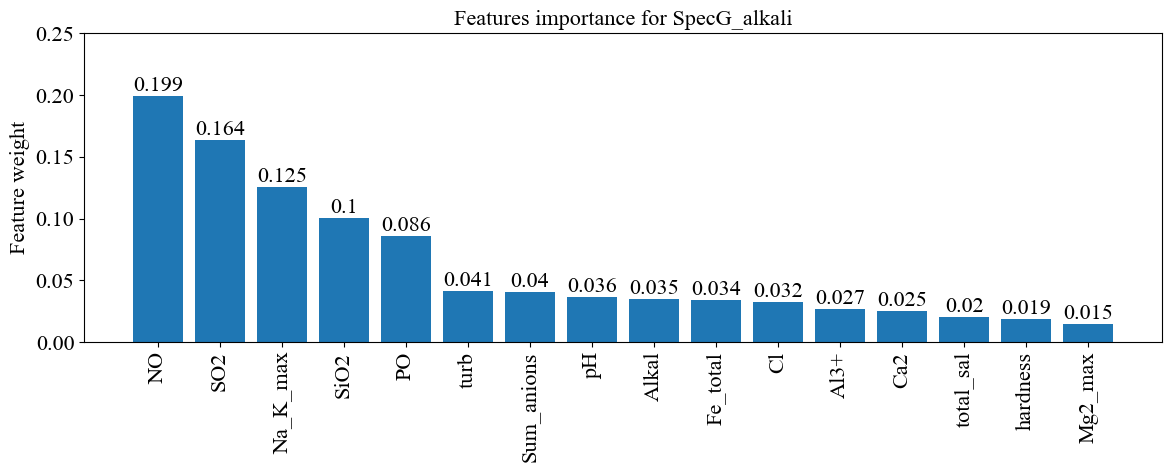

In [31]:
feature_importance_selector(X=df_Alcaline.drop(columns=['SpecG_alkali', 'Sum_cations']), 
                            y=df_Alcaline.SpecG_alkali,
                            engine='catboost')

# Pairplot

In [18]:
def pairplot(df, hue):
    plt.figure(figsize=(50,50))
    sns.pairplot(df, hue=hue, palette = "viridis")
    #plt.tight_layout()
    plt.savefig(f'pictures/pairlpot_{hue}.png', dpi = 300, transparent = True)
    plt.show()

## F_cycle

<Figure size 5000x5000 with 0 Axes>

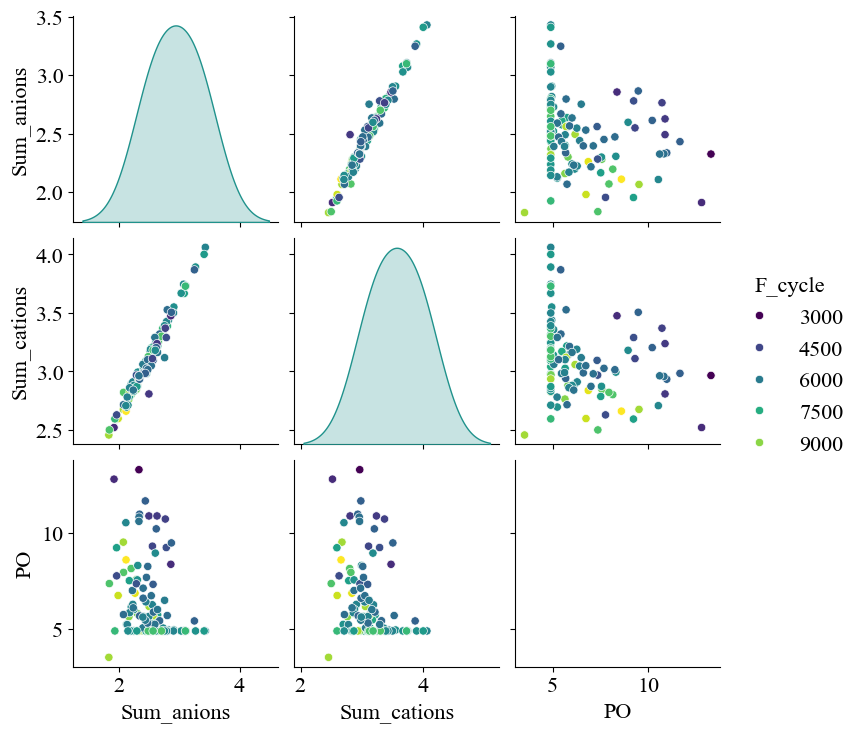

In [19]:
pairplot(df=df_F_cycle[['Sum_anions', 'Sum_cations', 'PO', 'F_cycle']], hue='F_cycle')

## Acid

<Figure size 5000x5000 with 0 Axes>

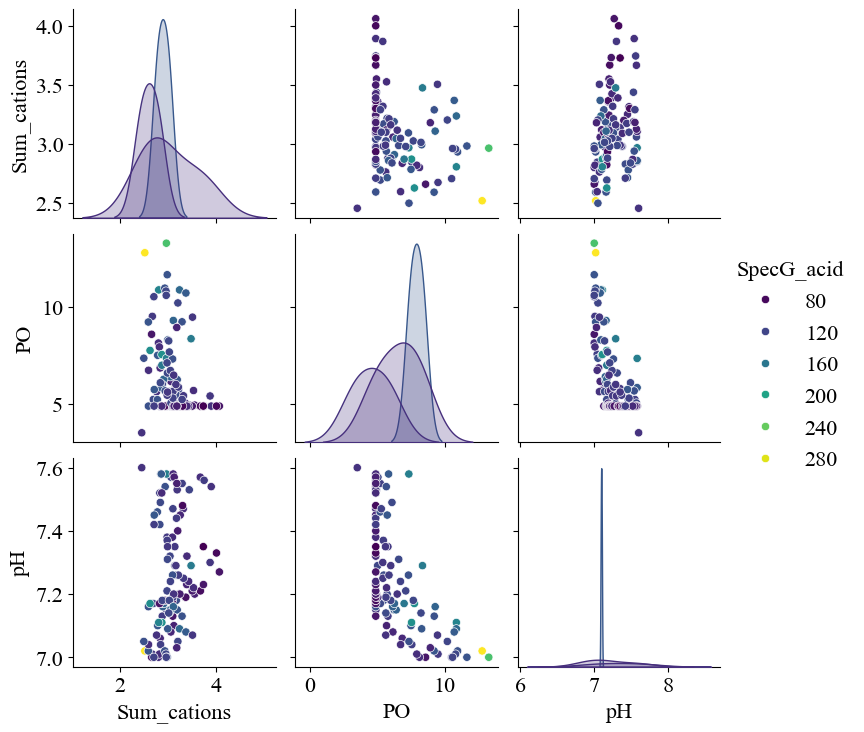

In [20]:
pairplot(df=df_Acid[['Sum_cations', 'PO', 'pH', 'SpecG_acid']], hue = 'SpecG_acid')

## Alcaline

<Figure size 5000x5000 with 0 Axes>

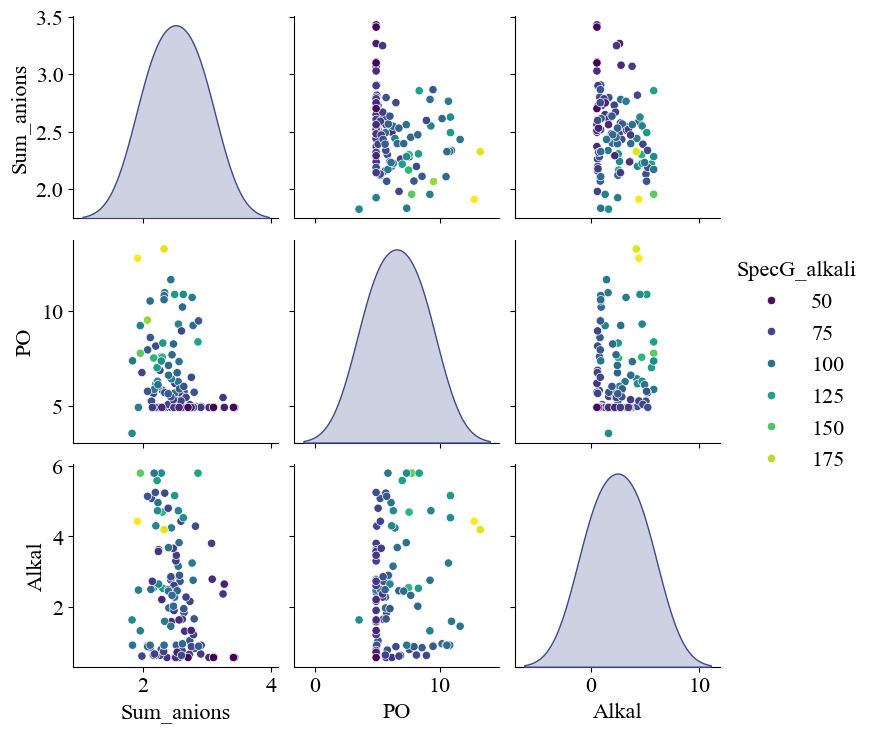

In [21]:
pairplot(df=df_Alcaline[['Sum_anions', 'PO', 'Alkal', 'SpecG_alkali']], hue = 'SpecG_alkali')